# HDBSCAN Clustering from Scratch
Enhanced with complex data and silhouette measurement.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.metrics import silhouette_score

## 1. Mock Data Generation

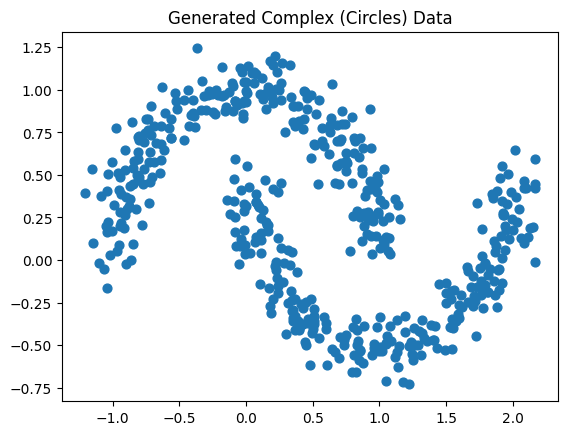

In [29]:
def get_complex_data():
    X, y = make_moons(n_samples=500, noise=0.1, random_state=42)
    return X, y

X, y_true = get_complex_data()
plt.scatter(X[:, 0], X[:, 1], s=40)
plt.title("Generated Complex (Circles) Data")
plt.show()

## 2. Implementation

In [33]:
class HDBSCANSimple:
    def __init__(self, min_pts=5):
        self.min_pts = min_pts

    def fit(self, X):
        n = len(X)
        # Calculate core distances
        cores = np.array([sorted([np.linalg.norm(X[i]-X[j]) for j in range(n)])[self.min_pts-1] for i in range(n)])
        
        # Mutual reachability distance adjacency matrix
        adj = np.zeros((n, n))
        for i in range(n):
            for j in range(i+1, n):
                d = max(cores[i], cores[j], np.linalg.norm(X[i]-X[j]))
                adj[i,j] = adj[j,i] = d
        
        # Prim's Algorithm for MST
        vst, min_d, parent = [False]*n, [float('inf')]*n, [-1]*n
        min_d[0], mst = 0, []
        for _ in range(n):
            # Find vertex with min distance among unvisited
            u = np.argmin([min_d[k] if not vst[k] else float('inf') for k in range(n)])
            vst[u] = True
            if parent[u] != -1: mst.append((parent[u], u, min_d[u]))
            for v in range(n):
                if not vst[v] and adj[u,v] < min_d[v]:
                    min_d[v], parent[v] = adj[u,v], u
        
        # Simplified Cluster Extraction: Cutting MST at a high threshold
        mst.sort(key=lambda x: x[2])
        # Using a percentile threshold for simplicity in this scratch version
        thresh = mst[int(0.65*len(mst))][2]
        
        self.labels = np.zeros(n)
        cid, visited = 1, [False]*n
        for i in range(n):
            if not visited[i]:
                q = [i]
                visited[i] = True
                while q:
                    curr = q.pop(0)
                    self.labels[curr] = cid
                    for u,v,w in mst:
                        if w < thresh:
                            nxt = v if u == curr else (u if v == curr else -1)
                            if nxt != -1 and not visited[nxt]:
                                visited[nxt] = True
                                q.append(nxt)
                cid += 1
        return self

## 3. Training & Measurement

In [34]:
model = HDBSCANSimple(min_pts=5)
model.fit(X)

if len(set(model.labels)) > 1:
    score = silhouette_score(X, model.labels)
    print(f"Finished fitting. Silhouette Score: {score:.4f}")
else:
    print("Only one cluster found.")
    score = 0

Finished fitting. Silhouette Score: -0.3824


## 4. Visualization

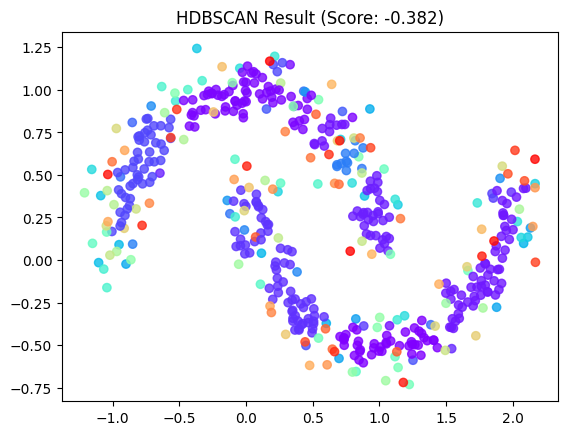

In [35]:
plt.scatter(X[:, 0], X[:, 1], c=model.labels, cmap='rainbow', alpha=0.8)
plt.title(f"HDBSCAN Result (Score: {score:.3f})")
plt.show()